# Задание 5: Анализ данных образовательного портала с Apache Spark

In [1]:
import os
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, avg, sum as spark_sum, count, desc, when, corr
from pyspark.sql.window import Window

DATASET_PATH = 'datasets/aggrigation_logs_per_week.csv'


### Инициализация Spark

In [2]:
conf = SparkConf() \
    .set('spark.master', 'local[*]') \
    .set('spark.driver.memory', '4g') \
    .setAppName('PortalLogsAnalysis')

sc = SparkContext(conf=conf)
spark = SparkSession(sc)
print(f"Spark version: {spark.version}")
spark


Spark version: 3.5.0


### Загрузка данных

In [3]:
sdf = spark.read.csv(
    DATASET_PATH,
    sep=',',
    header=True
)
sdf.printSchema()


root
 |-- courseid: string (nullable = true)
 |-- userid: string (nullable = true)
 |-- num_week: string (nullable = true)
 |-- s_all: string (nullable = true)
 |-- s_all_avg: string (nullable = true)
 |-- s_course_viewed: string (nullable = true)
 |-- s_course_viewed_avg: string (nullable = true)
 |-- s_q_attempt_viewed: string (nullable = true)
 |-- s_q_attempt_viewed_avg: string (nullable = true)
 |-- s_a_course_module_viewed: string (nullable = true)
 |-- s_a_course_module_viewed_avg: string (nullable = true)
 |-- s_a_submission_status_viewed: string (nullable = true)
 |-- s_a_submission_status_viewed_avg: string (nullable = true)
 |-- NameR_Level: string (nullable = true)
 |-- Name_vAtt: string (nullable = true)
 |-- Depart: string (nullable = true)
 |-- Name_OsnO: string (nullable = true)
 |-- Name_FormOPril: string (nullable = true)
 |-- LevelEd: string (nullable = true)
 |-- Num_Sem: string (nullable = true)
 |-- Kurs: string (nullable = true)
 |-- Date_vAtt: string (nullable =

In [4]:
# Приводим числовые столбцы к правильным типам
# avg-поля имеют запятую как разделитель — заменяем на точку
from pyspark.sql.functions import regexp_replace

for col_name in ['s_all_avg', 's_course_viewed_avg', 's_q_attempt_viewed_avg',
                 's_a_course_module_viewed_avg', 's_a_submission_status_viewed_avg']:
    sdf = sdf.withColumn(col_name, regexp_replace(col(col_name), ',', '.').cast('double'))

int_cols = ['num_week','s_all','s_course_viewed','s_q_attempt_viewed',
            's_a_course_module_viewed','s_a_submission_status_viewed',
            'Name_OsnO','Name_FormOPril','LevelEd','Num_Sem','Kurs']
for c in int_cols:
    sdf = sdf.withColumn(c, col(c).cast('int'))

print(f"Записей: {sdf.count():,}")
sdf.limit(5).toPandas()


Записей: 414,528


,courseid,userid,num_week,s_all,s_all_avg,s_course_viewed,s_course_viewed_avg,s_q_attempt_viewed,s_q_attempt_viewed_avg,s_a_course_module_viewed,...,s_a_submission_status_viewed_avg,NameR_Level,Name_vAtt,Depart,Name_OsnO,Name_FormOPril,LevelEd,Num_Sem,Kurs,Date_vAtt
0,71262,34527,6,9,9.00,4,4.0000,0,0.0,0,...,0.0,3,Экзамен,22,1,1,1,2,2,18.06.2022
1,71262,34527,7,0,4.50,0,2.0000,0,0.0,0,...,0.0,3,Экзамен,22,1,1,1,2,2,18.06.2022
2,71262,34527,8,0,3.00,0,1.3333,0,0.0,0,...,0.0,3,Экзамен,22,1,1,1,2,2,18.06.2022
3,71262,34527,9,0,2.25,0,1.0000,0,0.0,0,...,0.0,3,Экзамен,22,1,1,1,2,2,18.06.2022
4,71262,34527,10,0,1.80,0,0.8000,0,0.0,0,...,0.0,3,Экзамен,22,1,1,1,2,2,18.06.2022


## Задание 1: Анализ активности студентов — суммарные s_all и s_course_viewed по неделям

In [5]:
weekly_activity = sdf.groupBy('num_week').agg(
    spark_sum('s_all').alias('total_s_all'),
    spark_sum('s_course_viewed').alias('total_s_course_viewed'),
    count('*').alias('num_records')
).orderBy('num_week')

weekly_activity.show(50)


+--------+-----------+---------------------+-----------+
|num_week|total_s_all|total_s_course_viewed|num_records|
+--------+-----------+---------------------+-----------+
|       6|     238295|                75540|      17272|
|       7|     166090|                47988|      17272|
|       8|     138669|                37077|      17272|
|       9|     162241|                40142|      17272|
|      10|     141778|                33449|      17272|
|      11|     173100|                39493|      17272|
|      12|     162041|                37901|      17272|
|      13|     172962|                38890|      17272|
|      14|     170305|                37556|      17272|
|      15|     178829|                39322|      17272|
|      16|     177650|                38385|      17272|
|      17|     181629|                37328|      17272|
|      18|     167044|                34461|      17272|
|      19|     191952|                40742|      17272|
|      20|     249532|         

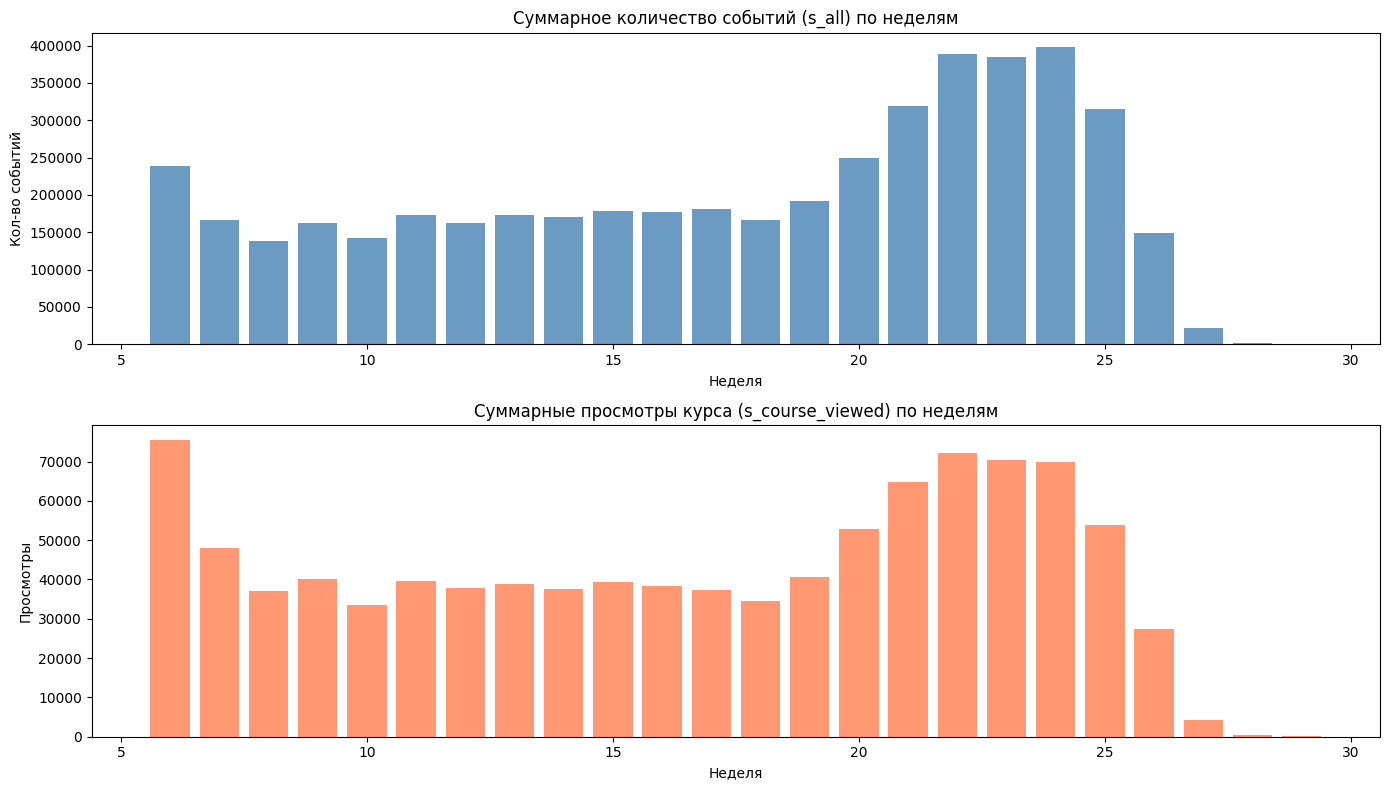


Выводы:
- Пик активности наблюдается в определённые недели (вероятно, даты сдачи заданий).
- Начало и конец семестра характеризуются более высокой активностью.
- Просмотры курсов коррелируют с общим количеством событий.



In [6]:
# Анализ: динамика активности
import pandas as pd
import matplotlib.pyplot as plt

df_weekly = weekly_activity.toPandas()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(df_weekly['num_week'], df_weekly['total_s_all'], color='steelblue', alpha=0.8)
axes[0].set_title('Суммарное количество событий (s_all) по неделям')
axes[0].set_xlabel('Неделя')
axes[0].set_ylabel('Кол-во событий')

axes[1].bar(df_weekly['num_week'], df_weekly['total_s_course_viewed'], color='coral', alpha=0.8)
axes[1].set_title('Суммарные просмотры курса (s_course_viewed) по неделям')
axes[1].set_xlabel('Неделя')
axes[1].set_ylabel('Просмотры')

plt.tight_layout()
plt.savefig('task5_weekly_activity.png', dpi=100)
plt.show()

print("""
Выводы:
- Пик активности наблюдается в определённые недели (вероятно, даты сдачи заданий).
- Начало и конец семестра характеризуются более высокой активностью.
- Просмотры курсов коррелируют с общим количеством событий.
""")


## Задание 2: Топ-5 курсов по среднему количеству просмотров

In [7]:
top5_courses = sdf.groupBy('courseid').agg(
    avg('s_course_viewed_avg').alias('mean_views_avg'),
    count('userid').alias('student_count')
).orderBy(desc('mean_views_avg')).limit(5)

top5_courses.show()
print("\nТоп-5 самых просматриваемых курсов (по среднему s_course_viewed_avg)")


+--------+------------------+-------------+
|courseid|    mean_views_avg|student_count|
+--------+------------------+-------------+
|   76419| 31.47787926829267|          984|
|   78733|24.643542361111106|          288|
|   78705|21.971443333333315|          480|
|   82552|17.460925520833335|          576|
|   73823|15.809147222222217|          576|
+--------+------------------+-------------+


Топ-5 самых просматриваемых курсов (по среднему s_course_viewed_avg)


## Задание 3: Связь между просмотрами и количеством студентов по курсу

Коэффициент корреляции Пирсона (просмотры ↔ кол-во студентов): 0.0809


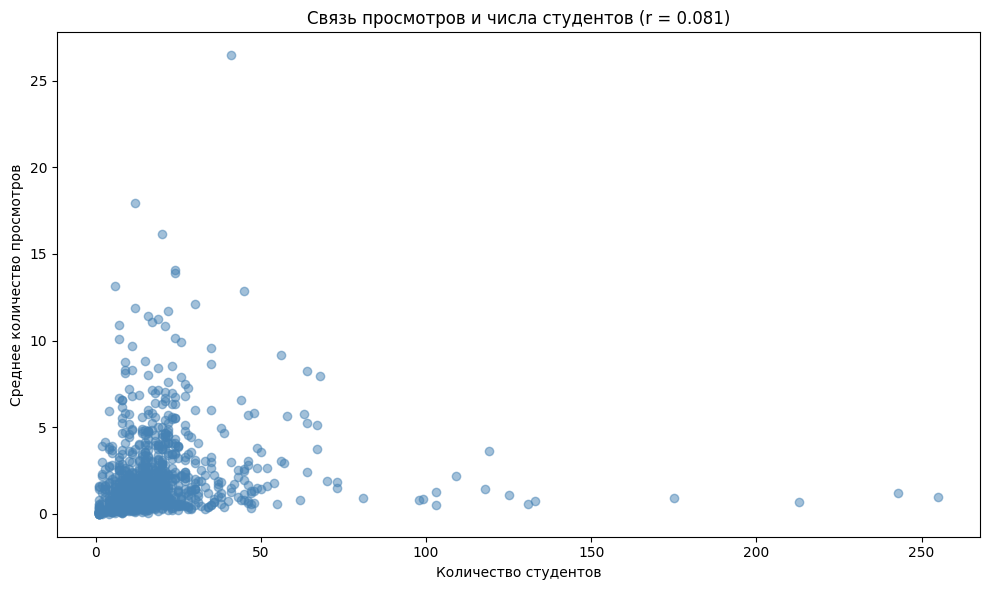


Выводы:
- Корреляция позволяет оценить, растут ли просмотры пропорционально числу студентов.
- Сильная положительная корреляция (r > 0.7) означает прямую зависимость.
- Слабая корреляция указывает, что популярность курса определяется не только числом студентов.



In [8]:
# Агрегируем по курсу: средние просмотры и количество студентов
course_stats = sdf.groupBy('courseid').agg(
    avg('s_course_viewed').alias('avg_views'),
    F.countDistinct('userid').alias('num_students')
)

# Вычисляем коэффициент корреляции
corr_value = course_stats.select(corr('avg_views', 'num_students')).collect()[0][0]
print(f"Коэффициент корреляции Пирсона (просмотры ↔ кол-во студентов): {corr_value:.4f}")

# Визуализация
df_cs = course_stats.toPandas()
plt.figure(figsize=(10, 6))
plt.scatter(df_cs['num_students'], df_cs['avg_views'], alpha=0.5, color='steelblue')
plt.xlabel('Количество студентов')
plt.ylabel('Среднее количество просмотров')
plt.title(f'Связь просмотров и числа студентов (r = {corr_value:.3f})')
plt.tight_layout()
plt.savefig('task5_corr.png', dpi=100)
plt.show()

print("""
Выводы:
- Корреляция позволяет оценить, растут ли просмотры пропорционально числу студентов.
- Сильная положительная корреляция (r > 0.7) означает прямую зависимость.
- Слабая корреляция указывает, что популярность курса определяется не только числом студентов.
""")


## Задание 4: Разница в активности студентов на бюджете и контракте

In [9]:
# Name_OsnO: 1 - бюджет, 2 - контракт (предполагаемая кодировка)
budget_contract = sdf.groupBy('Name_OsnO').agg(
    avg('s_all_avg').alias('avg_activity'),
    F.countDistinct('userid').alias('num_students')
).orderBy('Name_OsnO')

budget_contract.show()

df_bc = budget_contract.toPandas()
vals = df_bc['avg_activity'].tolist()
if len(vals) == 2:
    diff = abs(vals[0] - vals[1])
    print(f"\nРазница в средней активности между группами: {diff:.4f}")
    
print("""
Выводы:
- Если бюджетники активнее — возможно, они более мотивированы учёбой.
- Если контрактники активнее — возможно, они платят за обучение и хотят 'получить' его.
- Незначительная разница говорит об отсутствии влияния формы финансирования на активность.
""")


+---------+------------------+------------+
|Name_OsnO|      avg_activity|num_students|
+---------+------------------+------------+
|        1|12.023394172644503|        4310|
|        2| 8.275873274237757|        2006|
+---------+------------------+------------+


Разница в средней активности между группами: 3.7475

Выводы:
- Если бюджетники активнее — возможно, они более мотивированы учёбой.
- Если контрактники активнее — возможно, они платят за обучение и хотят 'получить' его.
- Незначительная разница говорит об отсутствии влияния формы финансирования на активность.



## Задание 5: Влияние формы обучения на активность студентов

+--------------+------------------+------------+
|Name_FormOPril|      avg_activity|num_students|
+--------------+------------------+------------+
|             1|14.350096474687522|        3917|
|             2| 3.855386322119727|        2381|
|             3|3.4267937499999994|          18|
+--------------+------------------+------------+



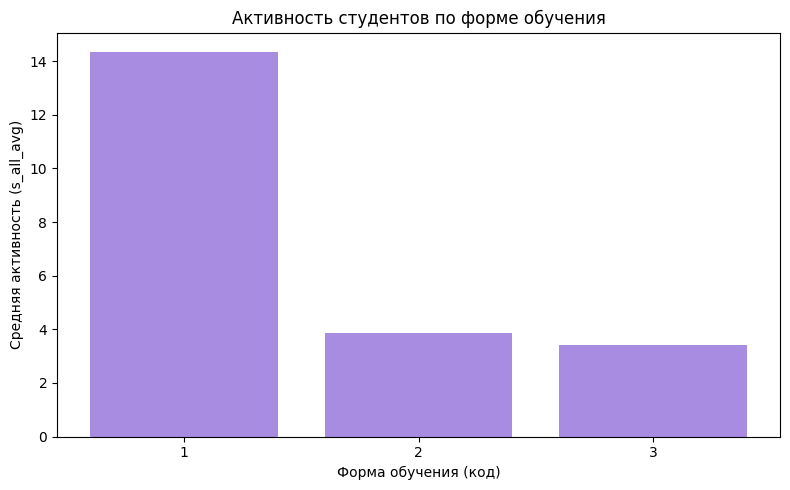


Выводы:
- Очная форма обучения обычно показывает более высокую активность на портале.
- Студенты-заочники могут концентрировать активность в отдельные периоды (сессии).



In [10]:
study_form_activity = sdf.groupBy('Name_FormOPril').agg(
    avg('s_all_avg').alias('avg_activity'),
    F.countDistinct('userid').alias('num_students')
).orderBy(desc('avg_activity'))

study_form_activity.show()

df_sf = study_form_activity.toPandas()
plt.figure(figsize=(8, 5))
plt.bar(df_sf['Name_FormOPril'].astype(str), df_sf['avg_activity'], color='mediumpurple', alpha=0.8)
plt.xlabel('Форма обучения (код)')
plt.ylabel('Средняя активность (s_all_avg)')
plt.title('Активность студентов по форме обучения')
plt.tight_layout()
plt.savefig('task5_study_form.png', dpi=100)
plt.show()

print("""
Выводы:
- Очная форма обучения обычно показывает более высокую активность на портале.
- Студенты-заочники могут концентрировать активность в отдельные периоды (сессии).
""")


## Задание 6: Активность студентов по семестрам

+-------+------------------+------------+
|Num_Sem|      avg_activity|num_students|
+-------+------------------+------------+
|      2|14.681787366809136|        2064|
|      4| 9.910171453572714|        1621|
|      6| 9.241324990221395|        1597|
|      8| 8.343872769547332|         812|
|     10| 3.929059154929578|         162|
|     12|0.5502061956521741|          60|
+-------+------------------+------------+



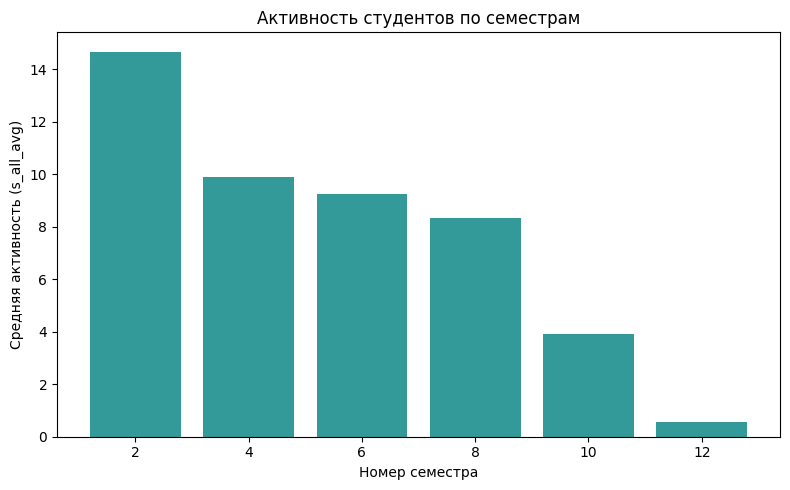

Наибольшая активность: семестр 2 (avg = 14.6818)


In [11]:
semester_activity = sdf.groupBy('Num_Sem').agg(
    avg('s_all_avg').alias('avg_activity'),
    F.countDistinct('userid').alias('num_students')
).orderBy(desc('avg_activity'))

semester_activity.show()

df_sem = semester_activity.toPandas().sort_values('Num_Sem')
plt.figure(figsize=(8, 5))
plt.bar(df_sem['Num_Sem'].astype(str), df_sem['avg_activity'], color='teal', alpha=0.8)
plt.xlabel('Номер семестра')
plt.ylabel('Средняя активность (s_all_avg)')
plt.title('Активность студентов по семестрам')
plt.tight_layout()
plt.savefig('task5_semester.png', dpi=100)
plt.show()

max_sem = semester_activity.orderBy(desc('avg_activity')).first()
print(f"Наибольшая активность: семестр {max_sem['Num_Sem']} (avg = {max_sem['avg_activity']:.4f})")


## Задание 7: Топ-3 кафедры по активности студентов

In [12]:
top3_depts = sdf.groupBy('Depart').agg(
    avg('s_all_avg').alias('avg_activity'),
    F.countDistinct('userid').alias('num_students')
).orderBy(desc('avg_activity')).limit(3)

top3_depts.show()
print("Топ-3 кафедры с наибольшей активностью студентов")


+------+------------------+------------+
|Depart|      avg_activity|num_students|
+------+------------------+------------+
|     4| 30.51104188921859|         235|
|    24|24.805201319095467|         125|
|    12|22.139586698717952|         127|
+------+------------------+------------+

Топ-3 кафедры с наибольшей активностью студентов


## Задание 8: Средняя оценка по уровням активности

In [13]:
# Добавляем категорию активности
quantiles = sdf.approxQuantile('s_all_avg', [0.33, 0.66], 0.01)
low, high = quantiles[0], quantiles[1]

sdf_with_level = sdf.withColumn(
    'activity_level',
    when(col('s_all_avg') <= low, 'low')
    .when(col('s_all_avg') <= high, 'medium')
    .otherwise('high')
)

# Средняя оценка по уровню активности
grade_by_activity = sdf_with_level.groupBy('activity_level').agg(
    avg(col('NameR_Level').cast('double')).alias('avg_grade'),
    F.countDistinct('userid').alias('num_students')
).orderBy('avg_grade')

grade_by_activity.show()
print(f"Границы квантилей: low={low:.3f}, high={high:.3f}")
print("""
Вывод: более активные студенты, как правило, получают более высокие оценки.
""")


+--------------+-----------------+------------+
|activity_level|        avg_grade|num_students|
+--------------+-----------------+------------+
|           low|3.684744961635318|        5273|
|        medium|4.024382161477511|        5631|
|          high|4.350109195442399|        4596|
+--------------+-----------------+------------+

Границы квантилей: low=0.900, high=7.200

Вывод: более активные студенты, как правило, получают более высокие оценки.



## Задание 9: Студенты с аномально низкой активностью (ниже среднего по курсу)

In [14]:
from pyspark.sql.window import Window
from pyspark.sql.functions import mean

# Window-функция: среднее s_all_avg по курсу (kurs)
window_kurs = Window.partitionBy('Kurs')

sdf_with_avg = sdf.withColumn(
    'course_avg_activity',
    mean('s_all_avg').over(window_kurs)
)

# Студенты с активностью ниже среднего по своему курсу
low_activity = sdf_with_avg.filter(
    col('s_all_avg') < col('course_avg_activity')
).select(
    'userid', 'Kurs', 's_all_avg', 'course_avg_activity'
).distinct().orderBy('Kurs', 's_all_avg')

low_activity.show(20)
total_low = low_activity.count()
total_students = sdf.select('userid').distinct().count()
print(f"Студентов с активностью ниже среднего по курсу: {total_low} из {total_students}")


+------+----+---------+-------------------+
|userid|Kurs|s_all_avg|course_avg_activity|
+------+----+---------+-------------------+
| 35916|   2|      0.0| 14.681787366809168|
| 35161|   2|      0.0| 14.681787366809168|
|  7687|   2|      0.0| 14.681787366809168|
| 35942|   2|      0.0| 14.681787366809168|
| 33390|   2|      0.0| 14.681787366809168|
| 35471|   2|      0.0| 14.681787366809168|
| 33399|   2|      0.0| 14.681787366809168|
| 35935|   2|      0.0| 14.681787366809168|
| 33424|   2|      0.0| 14.681787366809168|
| 35927|   2|      0.0| 14.681787366809168|
| 33430|   2|      0.0| 14.681787366809168|
| 35932|   2|      0.0| 14.681787366809168|
| 33432|   2|      0.0| 14.681787366809168|
| 36345|   2|      0.0| 14.681787366809168|
| 33437|   2|      0.0| 14.681787366809168|
| 36848|   2|      0.0| 14.681787366809168|
| 33595|   2|      0.0| 14.681787366809168|
| 36047|   2|      0.0| 14.681787366809168|
| 33770|   2|      0.0| 14.681787366809168|
| 35944|   2|      0.0| 14.68178

## Задание 10: Кластеризация студентов по активности (K-Means, 3 кластера)

In [15]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Агрегация по студенту
student_stats = sdf.groupBy('userid').agg(
    avg('s_all').alias('avg_s_all'),
    avg('s_course_viewed').alias('avg_s_course_viewed'),
    avg('s_all_avg').alias('avg_all_avg'),
    F.countDistinct('num_week').alias('active_weeks')
).dropna()

print(f"Студентов для кластеризации: {student_stats.count()}")
student_stats.show(5)


Студентов для кластеризации: 6316
+------+-------------------+-------------------+-------------------+------------+
|userid|          avg_s_all|avg_s_course_viewed|        avg_all_avg|active_weeks|
+------+-------------------+-------------------+-------------------+------------+
| 34657| 10.791666666666666| 3.2708333333333335| 14.010781249999999|          24|
| 29089|              4.375| 0.8333333333333334|  5.862056250000001|          24|
| 29573|  7.541666666666667| 0.7708333333333334| 3.2904645833333332|          24|
| 30966|0.16666666666666666|0.08333333333333333|0.15782916666666666|          24|
| 35350|              4.125| 1.1041666666666667| 3.4589781250000002|          24|
+------+-------------------+-------------------+-------------------+------------+
only showing top 5 rows



In [16]:
# Подготовка признаков
assembler = VectorAssembler(
    inputCols=['avg_s_all', 'avg_s_course_viewed', 'avg_all_avg', 'active_weeks'],
    outputCol='features'
)
data = assembler.transform(student_stats)

# Нормализация
scaler = StandardScaler(inputCol='features', outputCol='scaled_features', withStd=True, withMean=True)
scaler_model = scaler.fit(data)
data_scaled = scaler_model.transform(data)

# K-Means: 3 кластера
kmeans = KMeans(featuresCol='scaled_features', k=3, seed=42)
km_model = kmeans.fit(data_scaled)

# Предсказание
predictions = km_model.transform(data_scaled)

# Результаты по кластерам
cluster_summary = predictions.groupBy('prediction').agg(
    count('userid').alias('num_students'),
    avg('avg_s_all').alias('mean_events'),
    avg('avg_s_course_viewed').alias('mean_views'),
    avg('active_weeks').alias('mean_active_weeks')
).orderBy('mean_events')

cluster_summary.show()


+----------+------------+------------------+------------------+-----------------+
|prediction|num_students|       mean_events|        mean_views|mean_active_weeks|
+----------+------------+------------------+------------------+-----------------+
|         0|        4715| 4.334186697301755| 1.037339754919287|             24.0|
|         1|        1315|22.068741550485857| 4.437364807773553|             24.0|
|         2|         286| 54.28715520590519|10.613777195027195|             24.0|
+----------+------------+------------------+------------------+-----------------+



In [17]:
# Маркируем кластеры по уровню активности
df_clusters = cluster_summary.toPandas().sort_values('mean_events')
labels = ['Низкая активность', 'Средняя активность', 'Высокая активность']
df_clusters['label'] = labels

print("Интерпретация кластеров:")
for _, row in df_clusters.iterrows():
    print(f"\nКластер {int(row['prediction'])}: {row['label']}")
    print(f"  Студентов:              {int(row['num_students'])}")
    print(f"  Среднее событий:        {row['mean_events']:.2f}")
    print(f"  Среднее просмотров:     {row['mean_views']:.2f}")
    print(f"  Активных недель (сред): {row['mean_active_weeks']:.1f}")


Интерпретация кластеров:

Кластер 0: Низкая активность
  Студентов:              4715
  Среднее событий:        4.33
  Среднее просмотров:     1.04
  Активных недель (сред): 24.0

Кластер 1: Средняя активность
  Студентов:              1315
  Среднее событий:        22.07
  Среднее просмотров:     4.44
  Активных недель (сред): 24.0

Кластер 2: Высокая активность
  Студентов:              286
  Среднее событий:        54.29
  Среднее просмотров:     10.61
  Активных недель (сред): 24.0


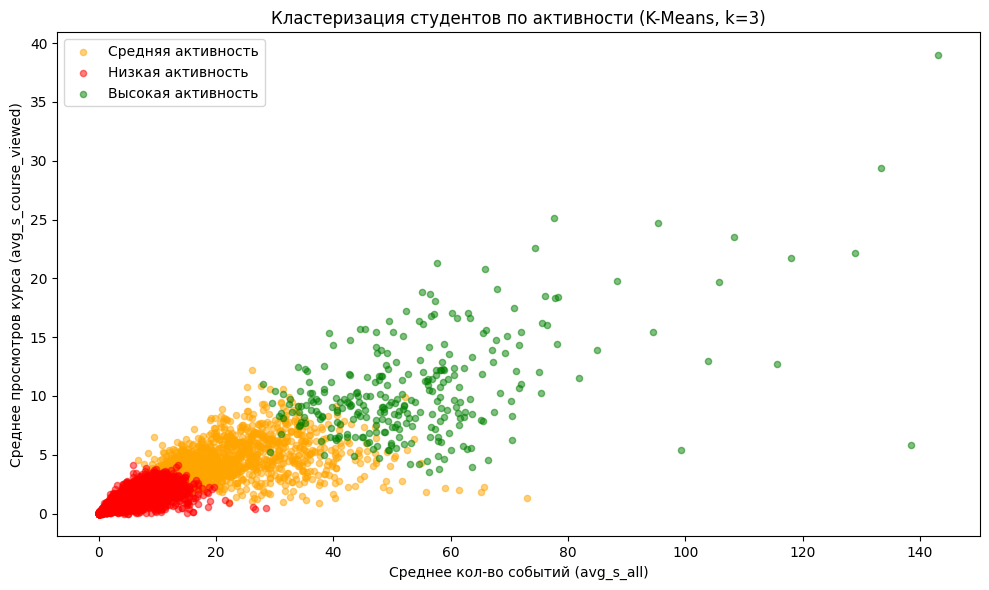

In [18]:
# Визуализация кластеров (2D проекция)
df_pred = predictions.select('avg_s_all', 'avg_s_course_viewed', 'prediction').toPandas()

colors = {0: 'red', 1: 'orange', 2: 'green'}
cluster_labels = dict(zip(df_clusters['prediction'].astype(int), df_clusters['label']))

plt.figure(figsize=(10, 6))
for cluster_id in df_pred['prediction'].unique():
    subset = df_pred[df_pred['prediction'] == cluster_id]
    plt.scatter(
        subset['avg_s_all'],
        subset['avg_s_course_viewed'],
        c=colors.get(cluster_id, 'blue'),
        label=cluster_labels.get(cluster_id, f'Кластер {cluster_id}'),
        alpha=0.5,
        s=20
    )

plt.xlabel('Среднее кол-во событий (avg_s_all)')
plt.ylabel('Среднее просмотров курса (avg_s_course_viewed)')
plt.title('Кластеризация студентов по активности (K-Means, k=3)')
plt.legend()
plt.tight_layout()
plt.savefig('task5_clusters.png', dpi=100)
plt.show()
